In [1]:
import pickle
with open("resoucre/laser.pickle","rb") as file:
    laser=pickle.load(file)

with open("resoucre/robot_position.pickle","rb") as file:
    robot=pickle.load(file)

In [2]:
from utlis import forward_kinematics_batch,process_laser
import numpy as np


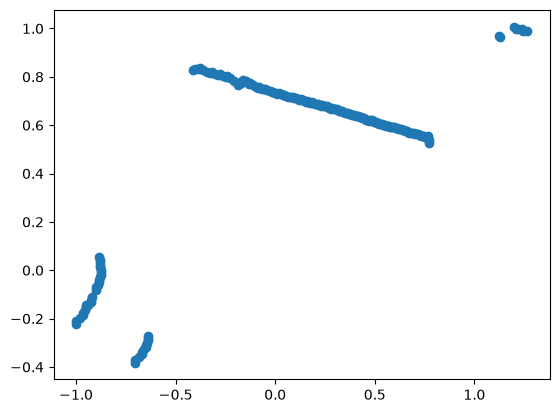

In [3]:
from matplotlib import pyplot as plt 
selected_points=process_laser(laser,robot)
plt.scatter(selected_points[:,0],selected_points[:,1])

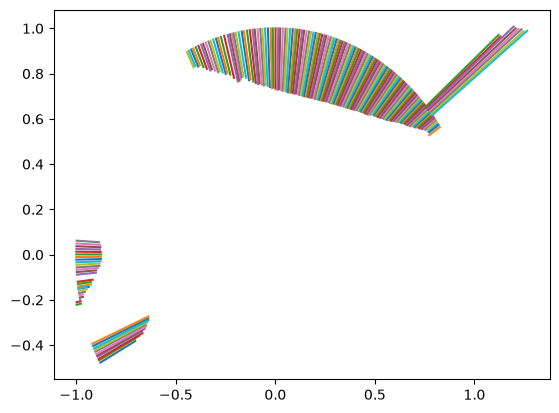

In [4]:
from shapely import LineString
# distance of each point from origin
norms = np.linalg.norm(selected_points, axis=1, keepdims=True)

# endpoints with same direction but length 1
end_points = selected_points / norms

obstacles=[]
for i,j in zip(selected_points,end_points):
    obstacles.append(LineString([i,j]))
    plt.plot([i[0],j[0]],[i[1],j[1]])

In [13]:
from RRT import RRTAngleBatch
rrt = RRTAngleBatch(
        # [0,0,0], 
        np.random.uniform(-np.pi,np.pi,3),
        obstacles, 
        tolerance=0.05, 
        step_size=0.2,
        batch_size=10,
        discriminant=0.015
    )

target=[np.random.uniform(-0.5,0.5),np.random.uniform(-0.5,0.5)]
# target=[0.4,0.6]
path=rrt.build_tree(target)


loading pickle


  9%|▉         | 91/1000 [00:00<00:00, 1200.48it/s]


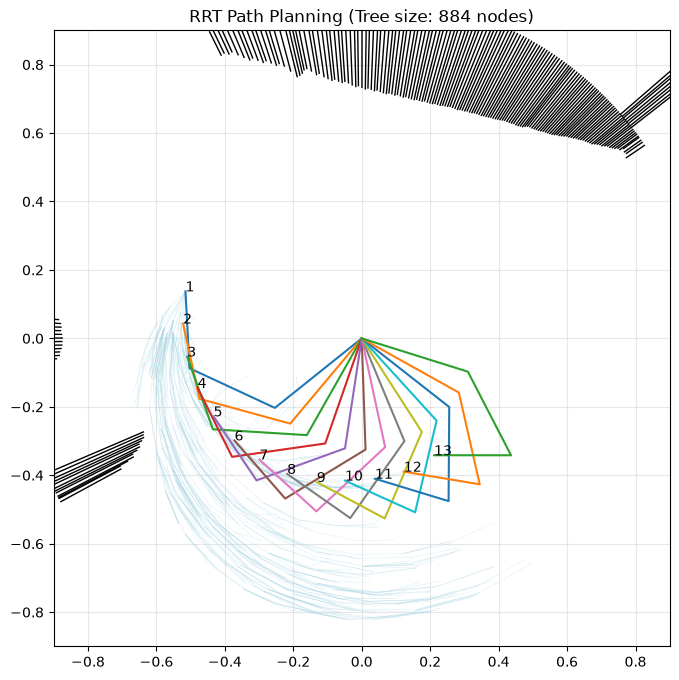

In [14]:
fig=rrt.render(path)


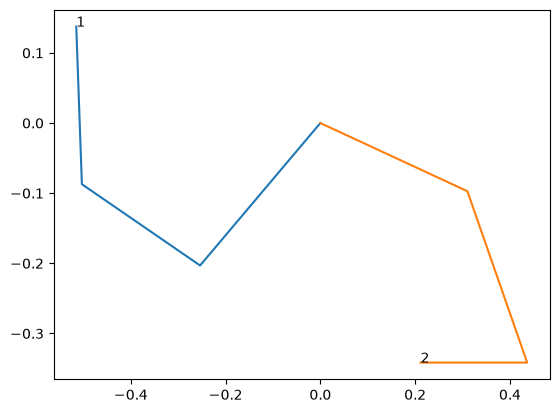

In [16]:
from RRT import smooth_path

new_path=smooth_path(path,rrt)

count=0
for i in forward_kinematics_batch(np.array(new_path)):
    plt.plot(i[:,0],i[:,1])
    count+=1
    plt.text(i[-1][0],i[-1][1],f"{count}")
